In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, ShuffleSplit, cross_val_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import RFE

In [2]:
rng = 1234

In [3]:
df = pd.read_csv("ortodoncja.csv")
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,normal
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,normal
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,horizontal
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,normal


In [4]:
direction_dict = {"horizontal": 0, "normal": 1, "vertical": 2}
df["growth direction"] = df["growth direction"].map(direction_dict)
df

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,0
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,0
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,0
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,0
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,1
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,1
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,0
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   9_SN/MP            446 non-null    float64
 1   9_Facial axis      446 non-null    float64
 2   9_Y-axis           446 non-null    float64
 3   9_Mn Base angle    446 non-null    float64
 4   9_Mn Ramus Angle   446 non-null    float64
 5   9_SNPog            446 non-null    float64
 6   9_SNB              446 non-null    float64
 7   9_SNA              446 non-null    float64
 8   9_SN/PP            446 non-null    float64
 9   9_ANB              446 non-null    float64
 10  9_AFH:PFH          446 non-null    float64
 11  9_PgNB             446 non-null    float64
 12  9_beta angle       446 non-null    float64
 13  12_SN/MP           446 non-null    float64
 14  12_Facial axis     446 non-null    float64
 15  12_Y-axis          446 non-null    float64
 16  12_Mn Base angle   446 non-null    fl

In [6]:
df.isnull().sum()

9_SN/MP              0
9_Facial axis        0
9_Y-axis             0
9_Mn Base angle      0
9_Mn Ramus Angle     0
9_SNPog              0
9_SNB                0
9_SNA                0
9_SN/PP              0
9_ANB                0
9_AFH:PFH            0
9_PgNB               0
9_beta angle         0
12_SN/MP             0
12_Facial axis       0
12_Y-axis            0
12_Mn Base angle     0
12_Mn Ramus Angle    0
12_SNPog             0
12_SNB               0
12_SNA               0
12_SN/PP             0
12_ANB               0
12_AFH:PFH           0
12_PgNB              0
12_beta angle        0
growth direction     0
dtype: int64

In [7]:
df.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,...,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,33.315033,88.428514,66.637249,1.946258,122.568512,77.290273,76.339302,80.718170,7.204316,-4.378868,...,121.245704,78.450767,77.290843,81.212121,7.165841,-3.921278,1.446325,1.160148,20.801461,0.623318
std,4.664109,3.559692,3.134645,1.407175,5.581123,3.140499,3.046515,3.404900,3.203708,2.058331,...,5.566098,3.130976,3.089604,3.452230,3.103847,2.158409,0.075403,0.727387,2.384866,0.554284
min,19.569295,75.471874,55.264537,-1.855797,106.273890,68.094393,67.770015,72.707404,-3.371575,-9.725989,...,104.789965,70.481570,70.187880,72.099648,-1.292949,-10.293067,1.244515,-1.068884,13.056881,0.000000
25%,30.083138,85.978142,64.481794,0.921260,118.904444,75.135247,74.086700,78.469479,5.089419,-5.792613,...,117.373239,76.424090,75.281835,78.721307,5.238621,-5.370657,1.393239,0.656741,19.067425,0.000000
50%,33.446964,88.256898,66.430186,1.937554,122.855447,77.308051,76.161821,80.618224,7.085342,-4.480021,...,121.047114,78.337574,77.129546,81.119388,7.262479,-4.014321,1.445952,1.162735,20.820688,1.000000
75%,36.433746,90.737761,68.700723,2.861721,126.266211,79.331829,78.261735,82.869704,9.165975,-2.935589,...,125.040958,80.338232,79.223116,83.389647,9.323639,-2.372826,1.501029,1.671685,22.318562,1.000000
max,49.286542,99.677516,75.115567,6.200186,137.616824,86.862239,84.787099,93.149888,18.750681,0.945465,...,139.166983,88.868366,86.982279,92.429272,15.053215,2.579310,1.650425,3.176099,29.655680,2.000000


In [8]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

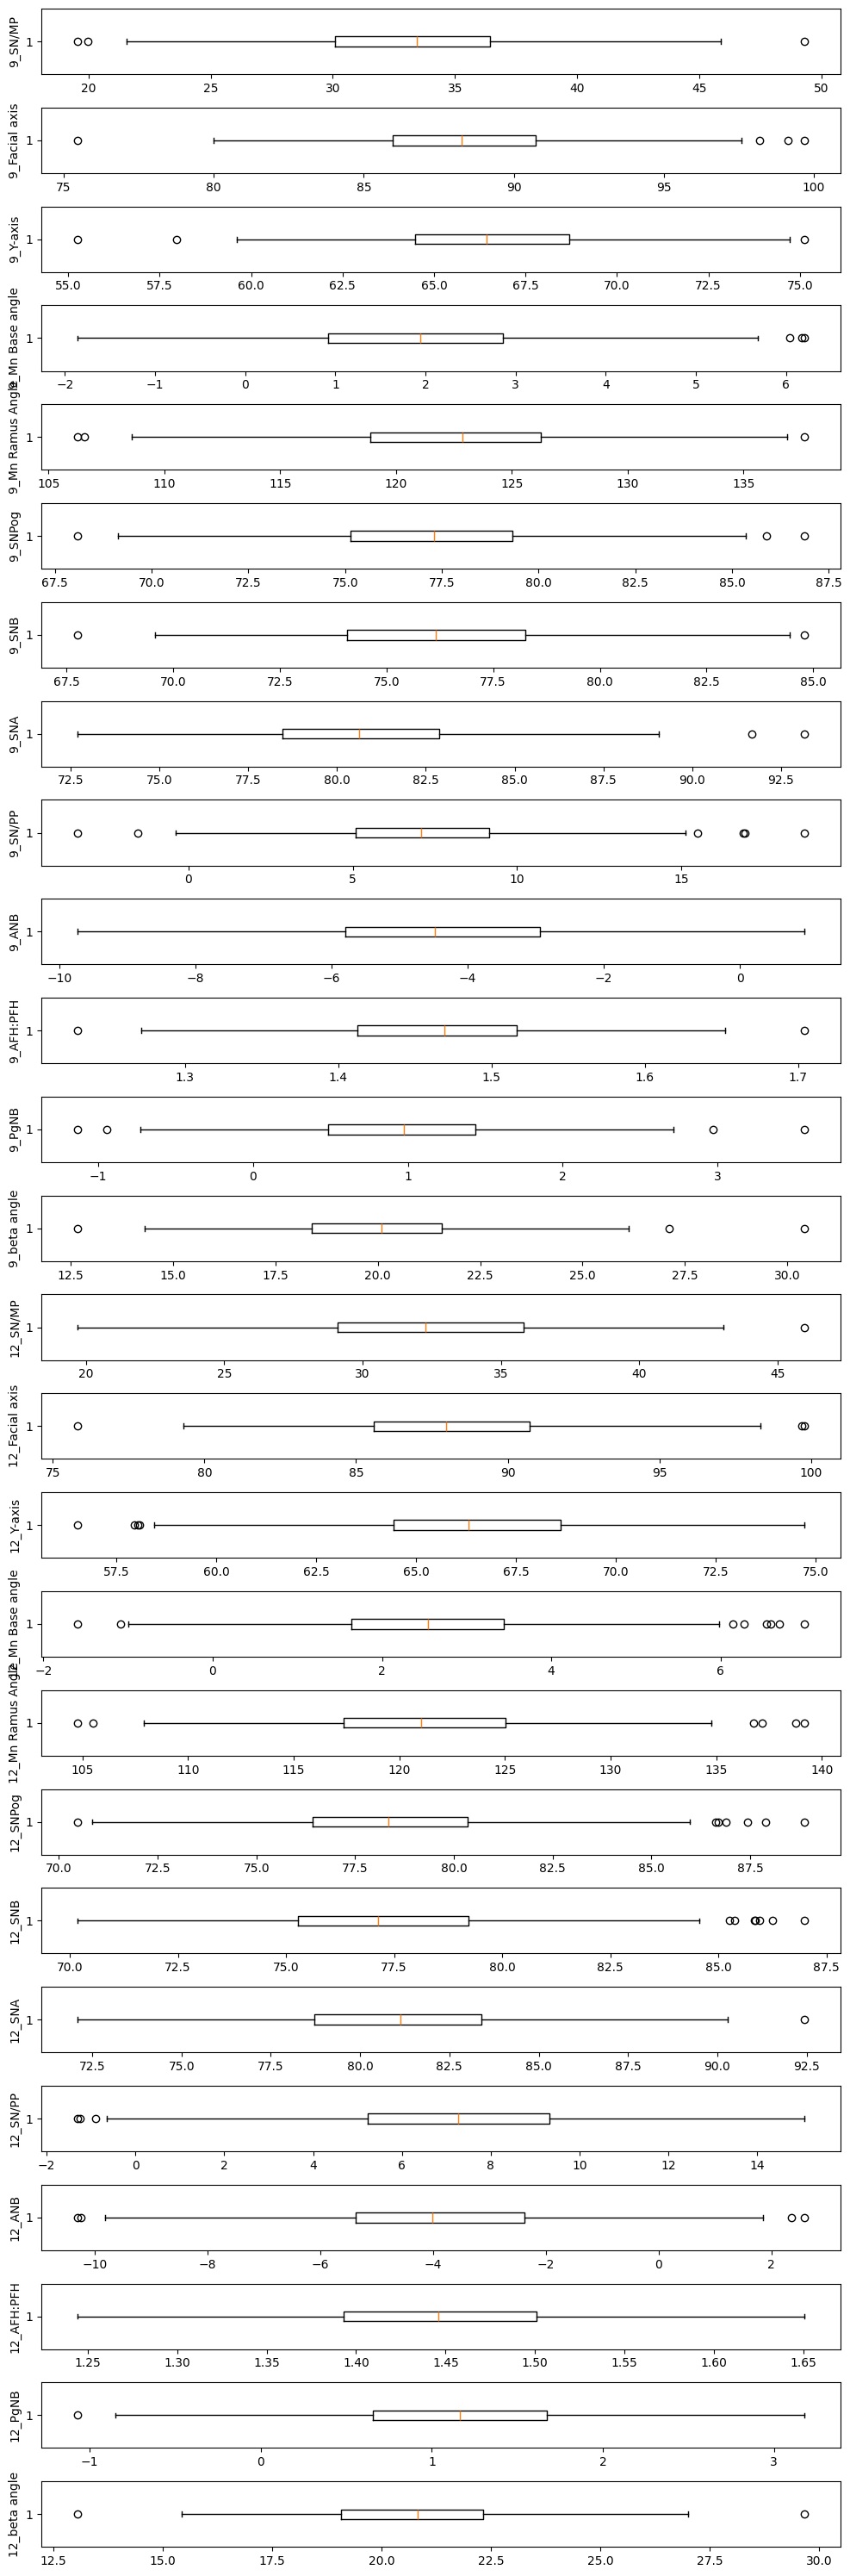

In [9]:
# https://www.geeksforgeeks.org/data-analysis/data-preprocessing-machine-learning-python/
fig, axs = plt.subplots(len(X.columns), 1, figsize=(10, 30), dpi=100)
for i, col in enumerate(X.columns):
    axs[i].boxplot(X[col], vert=False)
    axs[i].set_ylabel(col)
fig.tight_layout()
plt.show()

In [10]:
rows_with_outliers = set()
n = X.shape[0]
for column in X.columns:
    q1 = X[column].quantile(0.25)
    q3 = X[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    for i in range(0, n):
        if (X.at[i, column] < lower_bound or X.at[i, column] > upper_bound):
            rows_with_outliers.add(i)

print(len(rows_with_outliers))
print(len(rows_with_outliers) / n)

43
0.09641255605381166


In [11]:
print(X.corr())

                    9_SN/MP  9_Facial axis  9_Y-axis  9_Mn Base angle  \
9_SN/MP            1.000000       0.670009  0.786822        -0.055448   
9_Facial axis      0.670009       1.000000  0.827440        -0.087434   
9_Y-axis           0.786822       0.827440  1.000000        -0.075763   
9_Mn Base angle   -0.055448      -0.087434 -0.075763         1.000000   
9_Mn Ramus Angle   0.614780       0.179197  0.196867        -0.035201   
9_SNPog           -0.705692      -0.585322 -0.824868         0.083623   
9_SNB             -0.635962      -0.509748 -0.768684         0.040858   
9_SNA             -0.457572      -0.268965 -0.527675         0.002971   
9_SN/PP            0.401536       0.315496  0.463147        -0.047212   
9_ANB             -0.184363      -0.309550 -0.264838         0.055559   
9_AFH:PFH          0.931447       0.530857  0.701860        -0.048370   
9_PgNB            -0.392075      -0.401299 -0.349517         0.193933   
9_beta angle      -0.711634      -0.255077 -0.25169

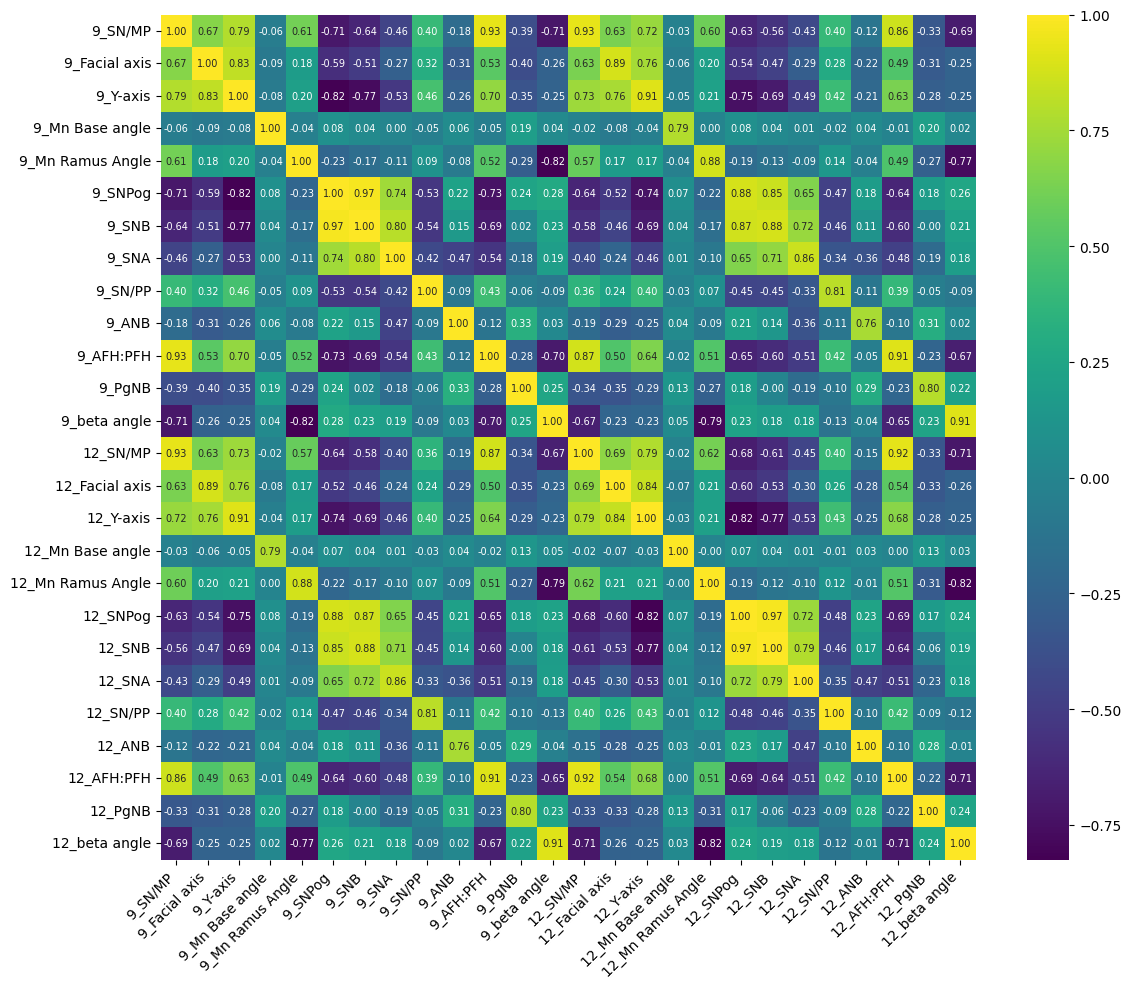

In [12]:
#ai generated
corr = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, ax=ax, cbar=True, cmap='viridis', annot_kws={'size': 7}, fmt='.2f')

ax.set_xticks([i + 0.5 for i in range(len(corr.columns))])
ax.set_yticks([i + 0.5 for i in range(len(corr.index))])

ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index, rotation=0)

plt.tight_layout()
plt.show()

In [13]:
values_occurences = Y.value_counts()
print(values_occurences)

growth direction
1    246
0    184
2     16
Name: count, dtype: int64


In [14]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], train_size=0.75, random_state=rng)

x_train = x_train.reset_index(drop=True) 
x_test  = x_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [15]:
class OutliersTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.bounds = {}
    def fit(self, X, y=None):
        for column in X.columns:
            q1 = X[column].quantile(0.25)
            q3 = X[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            self.bounds[column] = (lower_bound, upper_bound)
        return self
    def transform(self, X):
        x_clone = X.copy()
        for column in x_clone.columns:
            lower_bound = self.bounds[column][0]
            upper_bound = self.bounds[column][1]
            x_clone[column] = x_clone[column].clip(lower=lower_bound, upper=upper_bound)
        return x_clone

In [16]:
class CorrelationDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold):
        self.columns_to_drop = set()
        self.threshold = threshold
    def fit(self, X, y=None):
        self.columns_to_drop = set()
        corre = X.corr()
        names = X.columns
        for row in names:
            for col in names:
                if (corre.loc[row, col] > self.threshold and row != col and row[0] == col[0] and row not in self.columns_to_drop):
                    self.columns_to_drop.add(col)
        return self
    def transform(self, X):
        x_clone = X.copy()
        for name in self.columns_to_drop:
            x_clone.drop(name, axis=1, inplace=True)
        return x_clone

In [17]:
def calculate_metrcs(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    return (accuracy, precision, f1, recall)

def print_metrics(metrics):
    print(f'Accuracy: {metrics[0] * 100:.2f}%')
    print(f'Precision: {metrics[1]:.3f}')
    print(f'F1 score: {metrics[2]:.3f}')
    print(f'Recall: {metrics[3]:.3f}')

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

forest_pipeline = ImbPipeline([
    ('outliers', OutliersTransformer()),
    ('correlation', CorrelationDropper(0.95)),
    ('scaling', StandardScaler()),
    ('smote', SMOTE(sampling_strategy='not majority', random_state=rng)),
    ('forest', RandomForestClassifier(random_state=rng))
])

params_grid = {
    'forest__n_estimators': [60, 120, 250, 300, 350],
    'forest__max_depth': [6, 8, 12, None],
    'forest__max_features': [4, 12, 16, 26],
    'forest__min_samples_leaf': [1, 2, 4, 8]
}

forest = GridSearchCV(estimator=forest_pipeline, param_grid=params_grid, scoring='f1_macro', n_jobs=-1, cv=kf)

forest.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=1234))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'forest__max_depth': [6, 8, ...], 'forest__max_features': [4, 12, ...], 'forest__min_samples_leaf': [1, 2, ...], 'forest__n_estimators': [60, 120, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more

In [19]:
y_pred = forest.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 81.25%
Precision: 0.725
F1 score: 0.770
Recall: 0.873


/home/Tomasz/Dokumenty/WSI_proj1/.venv/lib64/python3.14/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=25 > n_features=24. There will be no feature selection and all features will be kept.
  warnings.warn(
/home/Tomasz/Dokumenty/WSI_proj1/.venv/lib64/python3.14/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=25 > n_features=24. There will be no feature selection and all features will be kept.
  warnings.warn(
/home/Tomasz/Dokumenty/WSI_proj1/.venv/lib64/python3.14/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=25 > n_features=24. There will be no feature selection and all features will be kept.
  warnings.warn(
/home/Tomasz/Dokumenty/WSI_proj1/.venv/lib64/python3.14/site-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=25 > n_features=24. There will be no feature selection and all features will be kept.
  warning

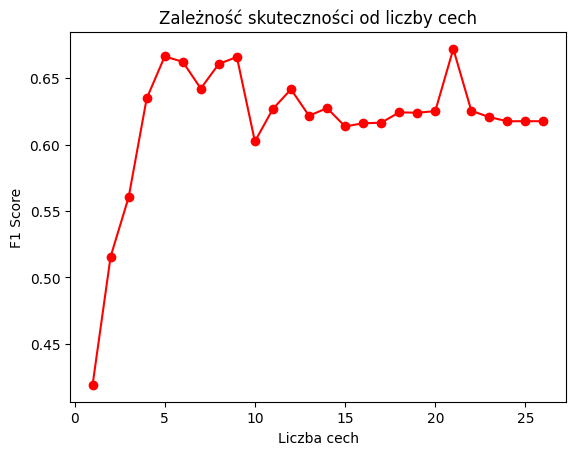

In [20]:
indices = []
values = []

for i in range(1, x_train.shape[1] + 1):
    forest_pipeline_rfe = ImbPipeline([
        ('outliers', OutliersTransformer()),
        ('correlation', CorrelationDropper(0.95)),
        ('scaling', StandardScaler()),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=rng)),
        ('rfe', RFE(estimator=RandomForestClassifier(random_state=rng), n_features_to_select=i)),
        ('forest', RandomForestClassifier(random_state=rng))
    ])

    results = cross_val_score(estimator=forest_pipeline_rfe, X=x_train, y=y_train, scoring='f1_macro', cv=kf, n_jobs=-1)
    mean = sum(results) / len(results)
    values.append(mean)
    indices.append(i)

# bazowane na kodzie wygenerowanym przez AI
plt.plot(indices, values, marker='o', linestyle='-', color='red')
plt.xlabel('Liczba cech')
plt.ylabel('F1 Score')
plt.title('Zależność skuteczności od liczby cech')
plt.show()

plt.show()

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=rng)

kneighbors_pipeline = ImbPipeline([
    ('outliers', OutliersTransformer()),
    ('correlation', CorrelationDropper(0.95)),
    ('scaling', StandardScaler()), 
    ('smote', SMOTE(sampling_strategy='not majority', random_state=rng)),
    ('neighbors', KNeighborsClassifier())
])

params_grid = {
    'neighbors__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40],
    'neighbors__weights': ['uniform', 'distance']
}

neighbors = GridSearchCV(estimator=kneighbors_pipeline, param_grid=params_grid, scoring='f1_macro', n_jobs=-1, cv=kf)
neighbors.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'neighbors__n_neighbors': [1, 2, ...], 'neighbors__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [22]:
y_pred = neighbors.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 65.18%
Precision: 0.573
F1 score: 0.596
Recall: 0.764


In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=rng)
logisitic_pipeline = ImbPipeline([
    ('outliers', OutliersTransformer()),
    ('correlation', CorrelationDropper(0.95)),
    ('scaling', StandardScaler()),
    ('smote', SMOTE(sampling_strategy='not majority', random_state=rng)),
    ('logreg', LogisticRegression(random_state=rng, max_iter=1000))
])

params_grid = {
    'logreg__C': [0.1, 0.3, 0.4, 0.5, 1.0, 3.0, 10.0, 100.0],
    'logreg__solver': ['lbfgs', 'newton-cholesky', 'newton-cg'],
    'logreg__class_weight': [None, 'balanced']
}

logreg = GridSearchCV(estimator=logisitic_pipeline, param_grid=params_grid, scoring='f1_macro', n_jobs=-1, cv=kf)
logreg.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=1234))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.1, 0.3, ...], 'logreg__class_weight': [None, 'balanced'], 'logreg__solver': ['lbfgs', 'newton-cholesky', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [24]:
y_pred = logreg.predict(x_test)
metrics = calculate_metrcs(y_test, y_pred)
print_metrics(metrics)

Accuracy: 70.54%
Precision: 0.621
F1 score: 0.655
Recall: 0.793


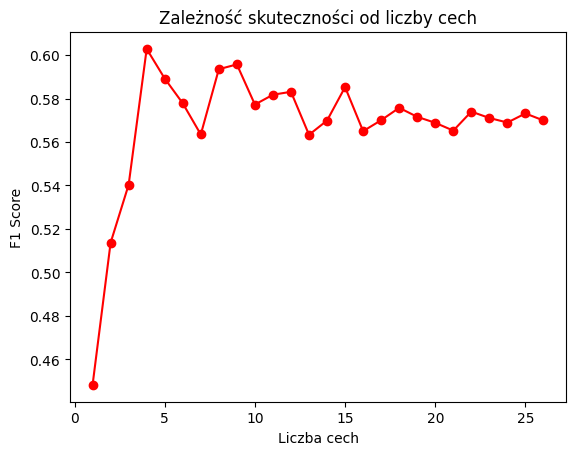

In [25]:
indices = []
values = []

for i in range(1, x_train.shape[1] + 1):
    logreg_pipeline_ref = ImbPipeline([
        ('outliers', OutliersTransformer()),
        ('scaling', StandardScaler()),
        ('smote', SMOTE(sampling_strategy='not majority', random_state=rng)),
        ('rfe', RFE(estimator=LogisticRegression(random_state=rng, max_iter=1000), n_features_to_select=i)),
        ('logreg', LogisticRegression(random_state=rng, max_iter=1000))
    ])
    
    results = cross_val_score(estimator=logreg_pipeline_ref, X=x_train, y=y_train, scoring='f1_macro', cv=kf, n_jobs=-1)
    mean = sum(results) / len(results)
    values.append(mean)
    indices.append(i)
    

# bazowane na kodzie wygenerowanym przez AI
plt.plot(indices, values, marker='o', linestyle='-', color='red')
plt.xlabel('Liczba cech')
plt.ylabel('F1 Score')
plt.title('Zależność skuteczności od liczby cech')
plt.show()

plt.show()